# Week-08 – AI/ML Applications in Civil Engineering
## Prediction of Municipal Solid Waste Generation Using Socio-Economic Indicators

**Name:** Harshita Pulavarti  
**Roll Number:** 24CE10087  

 ## Introduction

Municipal Solid Waste (MSW) generation is a critical environmental challenge influenced by socio-economic and demographic factors. With rapid urbanization and economic growth, understanding the drivers of waste generation has become essential for sustainable development and policy planning.

This study aims to analyze the relationship between socio-economic indicators such as GDP, HDI, employment ratio, government expenditure on education, and adult population with MSW generation.

Machine learning models are developed to predict MSW generation based on these variables.

## Dataset Description

The dataset consists of multiple countries and includes the following variables:

- **Year**: Time dimension
- **Location**: Country name
- **GDP**: Economic output
- **HDI**: Human Development Index
- **EMP_POP**: Employment-to-population ratio
- **GEE**: Government Expenditure on Education
- **Adult_pop**: Adult population
- **MSW_Generated**: Target variable (waste generated)

The dataset provides a comprehensive view of socio-economic conditions influencing waste generation.

## Importing Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_absolute_error

sns.set(style='whitegrid')

## Loading Dataset

In [24]:

df = pd.read_excel("msw generation.xlsx")
df.head()

,Year,Location,GDP,HDI,EMP_POP,GEE,Adult_pop,MSW_Generated
0,2020,Argentina,8489.332,0.841,49.602,5.27690,64.507475,416.1
1,2020,Belize,5210.543,0.705,51.128,5.21632,66.619841,277.4
2,2020,Bolivia,3172.556,0.691,64.177,8.43711,63.326175,208.1
3,2020,Brazil,7057.072,0.758,52.031,5.77150,69.644640,379.6
4,2020,Chile,13056.638,0.849,50.196,5.62993,68.960370,419.8


In [25]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 474 entries, 0 to 473
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           474 non-null    int64  
 1   Location       474 non-null    object 
 2   GDP            474 non-null    float64
 3   HDI            474 non-null    float64
 4   EMP_POP        474 non-null    float64
 5   GEE            474 non-null    float64
 6   Adult_pop      474 non-null    float64
 7   MSW_Generated  474 non-null    float64
dtypes: float64(6), int64(1), object(1)
memory usage: 29.8+ KB


,Year,GDP,HDI,EMP_POP,GEE,Adult_pop,MSW_Generated
count,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000
mean,2013.056962,24301.424977,0.804316,56.236833,4.882703,65.960960,405.785443
std,3.982377,24294.654308,0.125759,9.451604,1.570919,4.833197,257.868432
min,2000.000000,282.000000,0.381801,27.722000,0.964399,47.258370,0.600000
25%,2010.000000,5272.250000,0.742818,50.698500,3.867522,64.626157,250.350000
50%,2014.000000,14906.530500,0.839820,56.192000,4.841745,66.445346,371.850000
75%,2016.000000,41081.250000,0.903000,61.208750,5.619546,68.505995,477.875000
max,2020.000000,143256.000000,0.960000,87.440000,13.512660,85.068404,1733.800000


## Data Preprocessing

The following steps were performed:

- Checked for missing values
- Removed non-numeric columns (Year and Location)
- Prepared dataset for analysis and modeling

In [26]:
# Missing values
df.isnull().sum()

Year             0
Location         0
GDP              0
HDI              0
EMP_POP          0
GEE              0
Adult_pop        0
MSW_Generated    0
dtype: int64

In [27]:
# Drop Year & Location
df_clean = df.drop(columns=['Year', 'Location'])

df_clean.head()

,GDP,HDI,EMP_POP,GEE,Adult_pop,MSW_Generated
0,8489.332,0.841,49.602,5.27690,64.507475,416.1
1,5210.543,0.705,51.128,5.21632,66.619841,277.4
2,3172.556,0.691,64.177,8.43711,63.326175,208.1
3,7057.072,0.758,52.031,5.77150,69.644640,379.6
4,13056.638,0.849,50.196,5.62993,68.960370,419.8


## Exploratory Data Analysis (EDA)
EDA was performed to understand relationships between variables and identify trends.

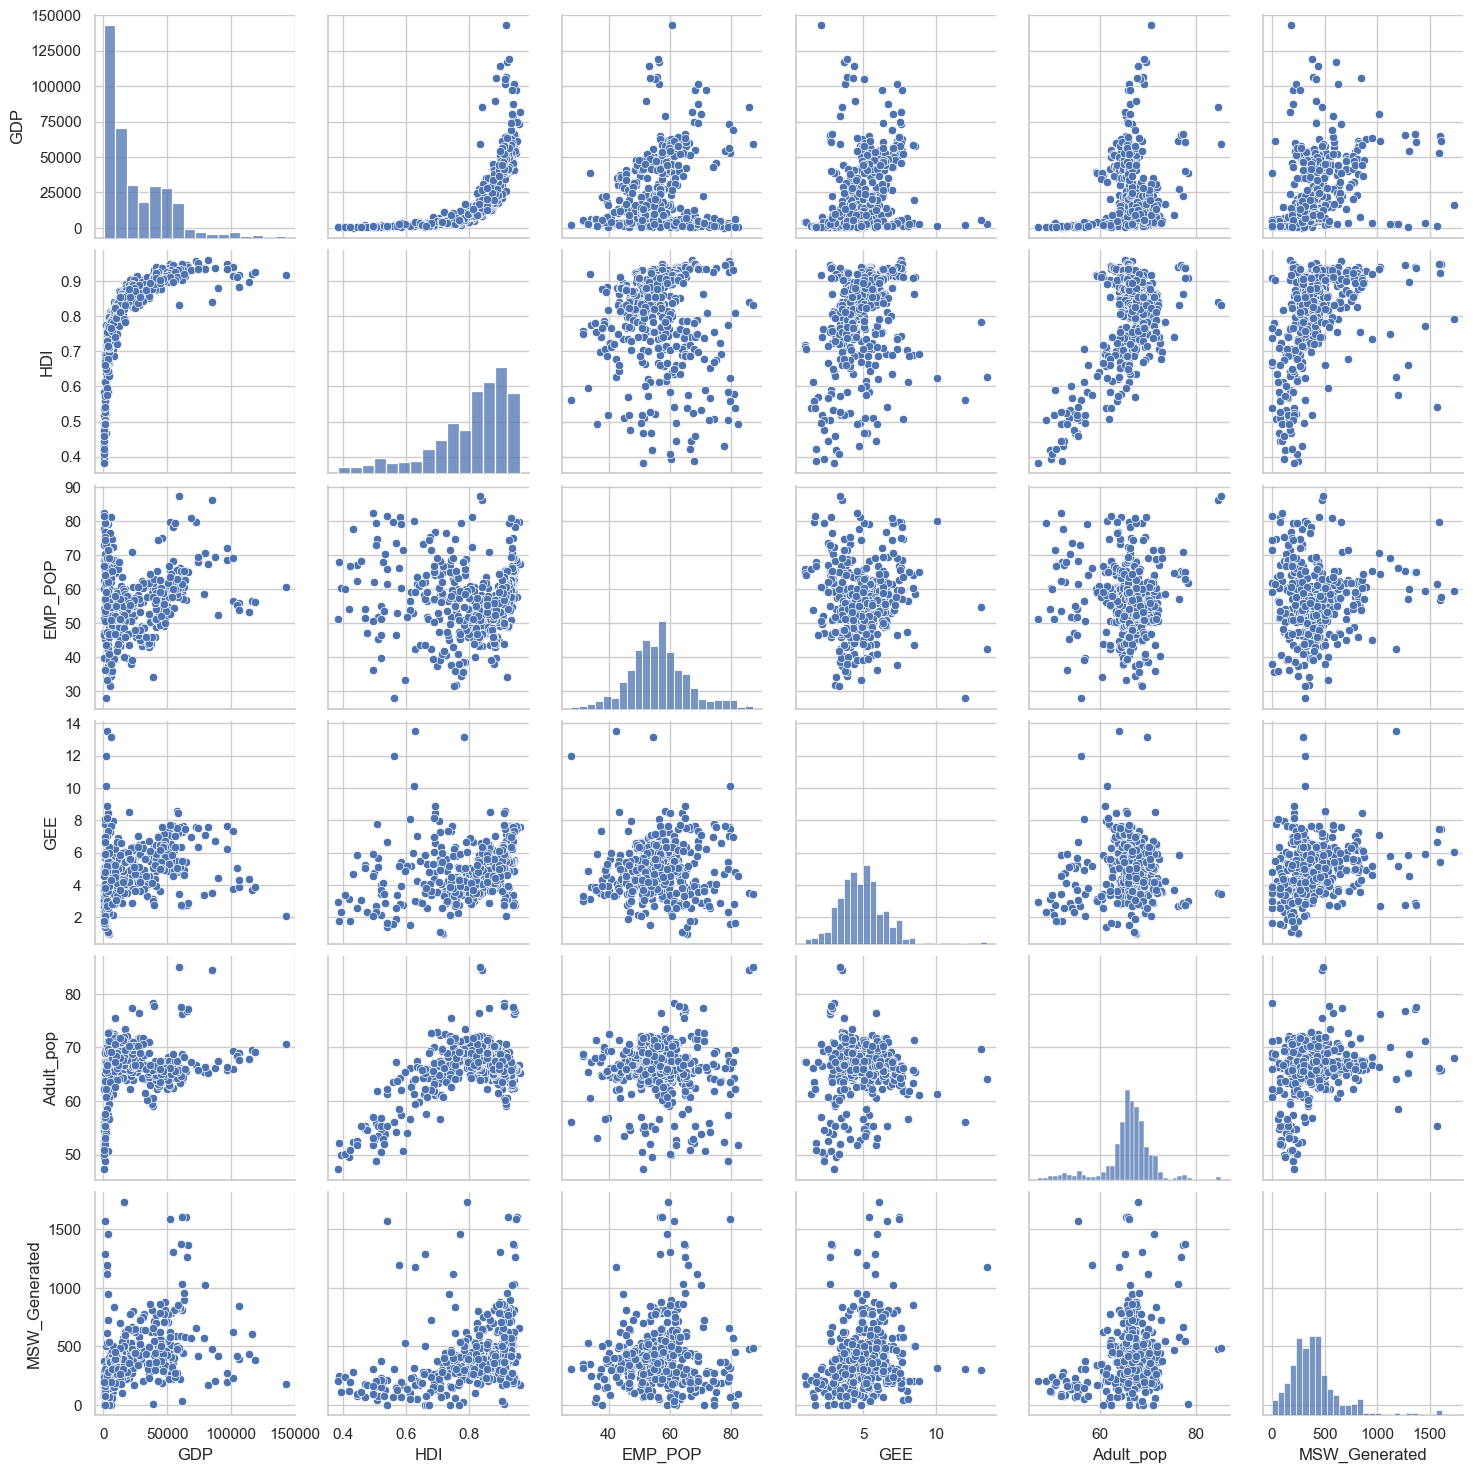

In [28]:
sns.pairplot(df_clean)
plt.show()

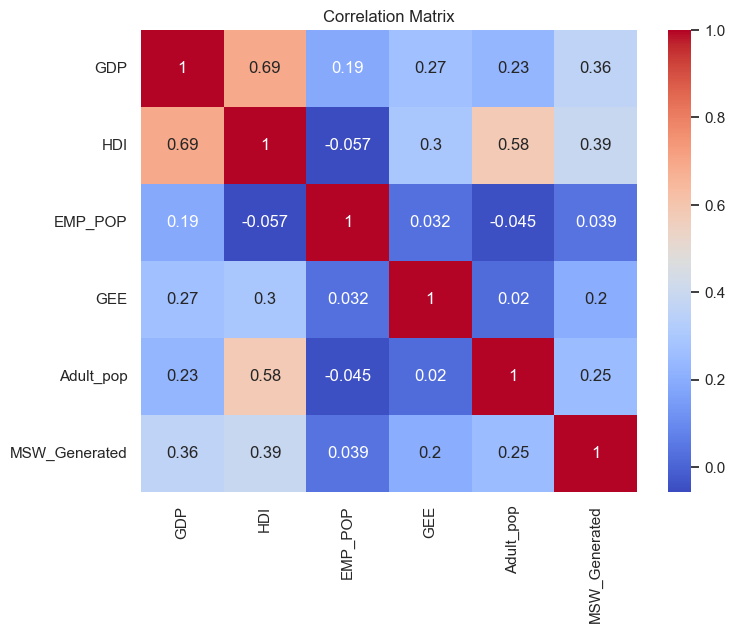

In [29]:
plt.figure(figsize=(8,6))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

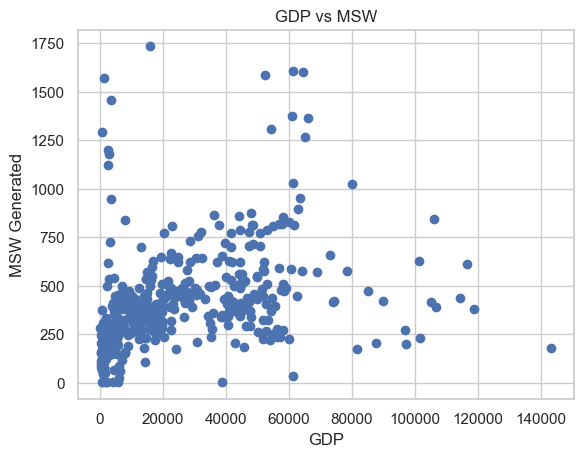

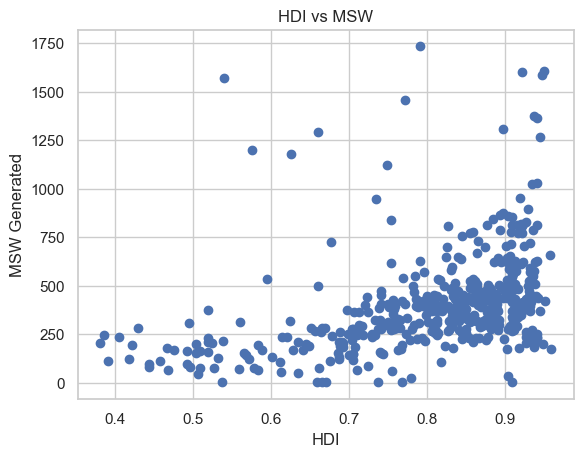

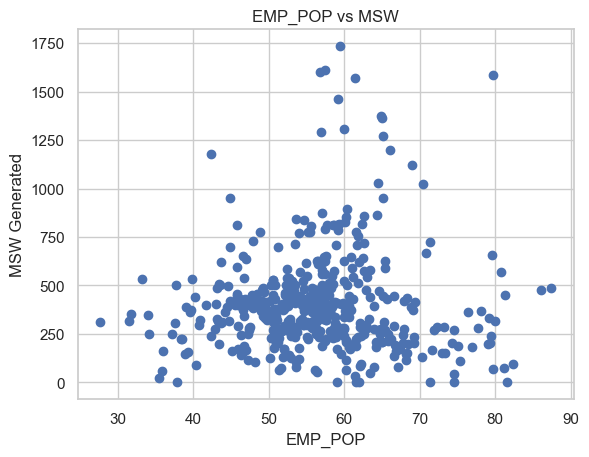

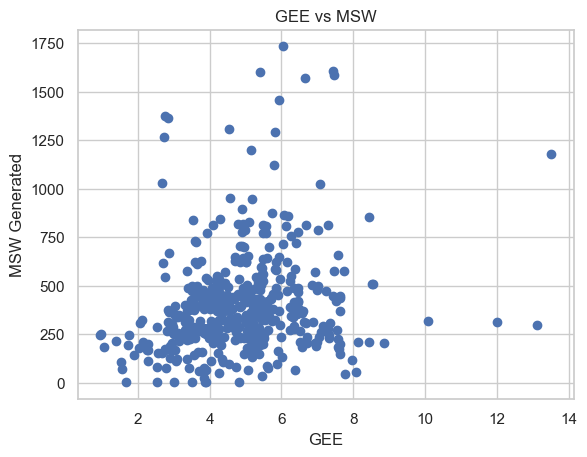

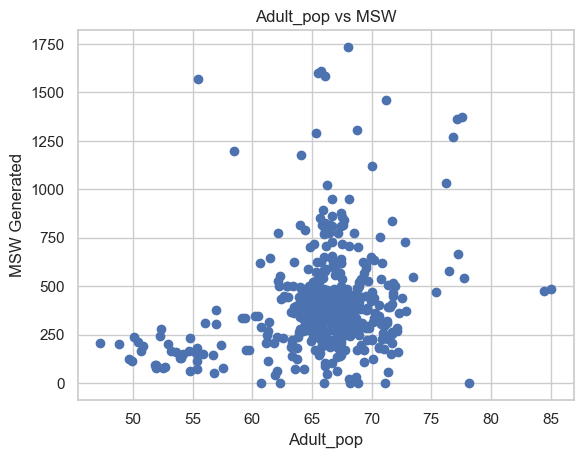

In [30]:
features = ['GDP', 'HDI', 'EMP_POP', 'GEE', 'Adult_pop']

for col in features:
    plt.figure()
    plt.scatter(df_clean[col], df_clean['MSW_Generated'])
    plt.xlabel(col)
    plt.ylabel("MSW Generated")
    plt.title(f"{col} vs MSW")
    plt.show()

## Observations:
- GDP shows strong positive correlation with MSW
- Adult Population is a major driver of waste generation
- HDI shows moderate correlation (lifestyle factor)
- GEE impact is mixed (policy vs consumption)
- EMP_POP moderately influences MSW


## Feature Selection

Feature selection was performed based on correlation with the target variable.

In [31]:
# Compute correlation with target again
corr = df_clean.corr(numeric_only=True)['MSW_Generated'].sort_values(ascending=False)

# Select top features (excluding target)
selected_features = corr.index[1:5].tolist()

print("Selected Features:", selected_features)

Selected Features: ['HDI', 'GDP', 'Adult_pop', 'GEE']


### Selected Features:
The top correlated variables were selected for model training.

## Data Splitting

In [32]:
X = df_clean[selected_features]
y = df_clean['MSW_Generated']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(379, 4) (95, 4)


## Model-01:Linear Regression

In [33]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression R2:", r2_lr)
print("Linear Regression MAE:", mae_lr)

Linear Regression R2: 0.1475598692762221
Linear Regression MAE: 148.23532354716409


### Interpretation:
Linear Regression provides a baseline model and assumes a linear relationship between variables.

## Model-02:Random Forest

In [34]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest R2:", r2_rf)
print("Random Forest MAE:", mae_rf)

Random Forest R2: 0.17524281408636933
Random Forest MAE: 152.4541894736842


### Interpretation:
Random Forest captures nonlinear relationships and interactions between variables effectively.

## Model-03:SVM

In [35]:
svm = SVR(kernel='rbf')
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

r2_svm = r2_score(y_test, y_pred_svm)
mae_svm = mean_absolute_error(y_test, y_pred_svm)

print("SVM R2:", r2_svm)
print("SVM MAE:", mae_svm)

SVM R2: 0.02482313411878645
SVM MAE: 157.05692511169607


### Interpretation:
SVM is sensitive to scaling and may underperform without normalization.

## Model Comparision

In [36]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "SVM"],
    "R2 Score": [r2_lr, r2_rf, r2_svm],
    "MAE": [mae_lr, mae_rf, mae_svm]
})

results

,Model,R2 Score,MAE
0,Linear Regression,0.147560,148.235324
1,Random Forest,0.175243,152.454189
2,SVM,0.024823,157.056925


## Results Visualization

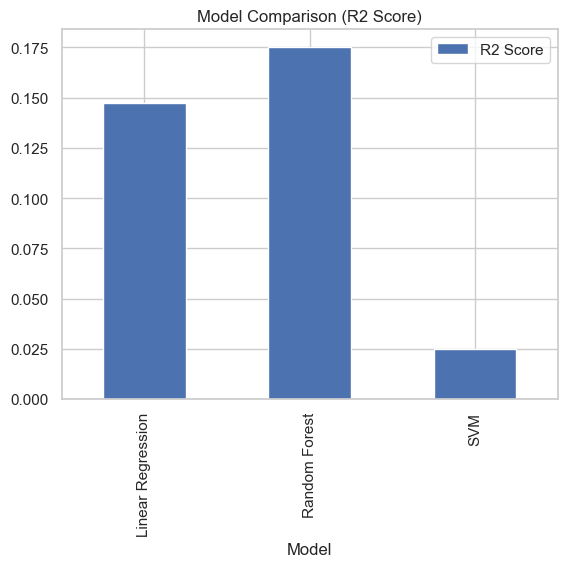

In [37]:
results.set_index("Model")[["R2 Score"]].plot(kind='bar')
plt.title("Model Comparison (R2 Score)")
plt.show()

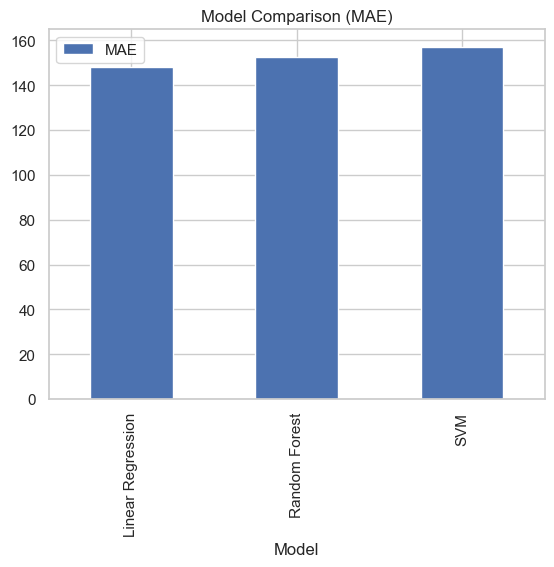

In [38]:
results.set_index("Model")[["MAE"]].plot(kind='bar')
plt.title("Model Comparison (MAE)")
plt.show()

## Discussion

- GDP and Adult Population emerged as the strongest predictors.
- Higher economic activity leads to increased consumption and waste.
- Population size directly impacts total waste generation.
- Random Forest outperformed other models due to its ability to model nonlinear relationships.

## Conclusion

This study successfully developed machine learning models to predict MSW generation using socio-economic indicators.

Key findings:
- Economic and demographic factors significantly influence waste generation.
- Random Forest model achieved the best performance.
- Predictive models can assist policymakers in planning sustainable waste management systems.

The approach demonstrates the importance of data-driven decision-making in environmental management.

## Key Takeaways:
- Waste generation is strongly tied to economic and demographic factors.
- Machine learning models can effectively predict MSW for planning purposes.
- Policymakers can use such models for sustainable waste management strategies.